In [2]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import cv2
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC, OneClassSVM
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics         import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120


In [3]:
DATASET_PATH = r'C:\Users\BALU LOHITH REDDY\Downloads\tobacco leaves'

FOLDER_TO_GRADE = {
    'gold':  (0, 'Grade A', 'Gold'),
    'green': (1, 'Grade B', 'Yellowish-Green'),
    'black': (2, 'Grade C', 'Dark Brown'),
}

GRADE_LABELS   = ['Grade A (Gold)', 'Grade B (Green)', 'Grade C (Black)']
SHORT_LABELS   = ['A', 'B', 'C']
IMG_SIZE       = (224, 224)
GRADER_FILE    = 'tobacco_grader.pkl'      # grade classifier
VALIDATOR_FILE = 'tobacco_validator.pkl'   # tobacco-only detector
RANDOM_STATE   = 42

In [4]:

def remove_background(img_bgr):
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    bg   = cv2.inRange(hsv, np.array([0, 0, 190]), np.array([180, 40, 255]))
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    bg   = cv2.morphologyEx(bg, cv2.MORPH_CLOSE, k)
    bg   = cv2.morphologyEx(bg, cv2.MORPH_OPEN,  k)
    mask = cv2.bitwise_not(bg)
    # Keep only the largest blob (the leaf itself)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask    = np.uint8(labels == largest) * 255
    return cv2.bitwise_and(img_bgr, img_bgr, mask=mask), mask



def color_features(img_bgr, mask):
    feats    = []
    has_mask = mask is not None and np.any(mask > 0)
    hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    h = (hsv[mask>0,0] if has_mask else hsv[:,:,0].flatten()).astype(np.float32)
    s = (hsv[mask>0,1] if has_mask else hsv[:,:,1].flatten()).astype(np.float32)
    v = (hsv[mask>0,2] if has_mask else hsv[:,:,2].flatten()).astype(np.float32)

    if len(h) == 0:
        return np.zeros(57, dtype=np.float32)

    h_hist,_ = np.histogram(h, bins=18, range=(0,180), density=True)
    s_hist,_ = np.histogram(s, bins=8,  range=(0,255), density=True)
    v_hist,_ = np.histogram(v, bins=8,  range=(0,255), density=True)
    feats.extend(h_hist); feats.extend(s_hist); feats.extend(v_hist)  # 34

    feats += [np.mean(h), np.std(h), np.median(h)]  # 3
    feats += [np.mean(s), np.std(s)]                 # 2
    feats += [np.mean(v), np.std(v)]                 # 2
    for p in [10,25,50,75,90]:                       # 5
        feats.append(float(np.percentile(v,p)) / 255.0)

    lab    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    lab_px = lab[mask>0] if has_mask else lab.reshape(-1,3)
    for ch in range(3):                              # 6
        feats.append(float(np.mean(lab_px[:,ch])))
        feats.append(float(np.std(lab_px[:,ch])))

    px     = (img_bgr[mask>0] if has_mask else img_bgr.reshape(-1,3)).astype(float)
    b_ch,g_ch,r_ch = px[:,0], px[:,1], px[:,2]
    total  = np.mean(r_ch)+np.mean(g_ch)+np.mean(b_ch)+1e-6
    feats += [np.mean(r_ch)/total, np.mean(g_ch)/total, np.mean(b_ch)/total]  # 3
    feats += [np.mean(r_ch)-np.mean(b_ch), np.mean(g_ch)-np.mean(b_ch)]       # 2
    return np.array(feats, dtype=np.float32)  # total = 57



def texture_features(img_bgr, mask):
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray  = cv2.resize(gray, (256, 256))
    feats = []
    glcm  = graycomatrix(gray, distances=[1,3,5],
                         angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=256, symmetric=True, normed=True)
    for prop in ['contrast','correlation','energy','homogeneity']:
        vals  = graycoprops(glcm, prop).flatten()
        feats += [float(np.mean(vals)), float(np.std(vals)),
                  float(np.min(vals)),  float(np.max(vals))]
    eps     = 1e-10
    entropy = -np.sum(glcm*np.log2(glcm+eps), axis=(0,1)).flatten()
    feats  += [float(np.mean(entropy)), float(np.std(entropy))]
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gm = np.sqrt(sx**2+sy**2).flatten()
    feats += [float(np.mean(gm)), float(np.std(gm)), float(np.percentile(gm,75))]
    feats.append(float(np.var(cv2.Laplacian(gray, cv2.CV_64F))))
    return np.array(feats, dtype=np.float32)  # total = 70



def shape_features(mask):
    if mask is None:
        return np.zeros(10, dtype=np.float32)
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros(10, dtype=np.float32)

    cnt  = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    if area < 200:
        return np.zeros(10, dtype=np.float32)

    x,y,w,h     = cv2.boundingRect(cnt)
    aspect_ratio = float(max(w,h)) / (min(w,h) + 1e-6)
    extent       = area / (w*h + 1e-6)

    hull      = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity  = area / (hull_area + 1e-6)

    perim            = cv2.arcLength(cnt, True)
    perim_area_ratio = (perim**2) / (area + 1e-6)
    equiv_diam       = np.sqrt(4*area/np.pi)

    eccentricity = 0.0
    if len(cnt) >= 5:
        el = cv2.fitEllipse(cnt)
        ma,MA = el[1]
        eccentricity = np.sqrt(1-(min(ma,MA)/(max(ma,MA)+1e-6))**2)

    hull_idx = cv2.convexHull(cnt, returnPoints=False)
    try:
        defects = cv2.convexityDefects(cnt, hull_idx)
        n_def   = len(defects) if defects is not None else 0
        max_def = float(np.max(defects[:,0,3])/256.0) if defects is not None else 0.0
    except:
        n_def, max_def = 0, 0.0

    img_area  = mask.shape[0] * mask.shape[1]
    norm_area = area / img_area

    return np.array([
        aspect_ratio,           # elongation
        extent,                 # fills bounding box
        solidity,               # convexity
        perim_area_ratio,       # boundary complexity
        equiv_diam / 224.0,     # normalised size
        eccentricity,           # oval-ness
        float(n_def),           # jagged edges
        max_def,                # deepest notch
        norm_area,              # relative area
        hull_area / (img_area + 1e-6),
    ], dtype=np.float32)  # total = 10



def vein_features(img_bgr, mask):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (256,256)).astype(np.float32)
    m_r  = cv2.resize(mask, (256,256)) if mask is not None else None

    feats = []
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        kernel   = cv2.getGaborKernel(
            ksize=(21,21), sigma=4.0, theta=theta,
            lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F
        )
        filtered = cv2.filter2D(gray, cv2.CV_32F, kernel)
        resp     = filtered[m_r>0] if (m_r is not None and np.any(m_r>0)) else filtered.flatten()

        feats.append(float(np.mean(np.abs(resp))))
        feats.append(float(np.std(resp)))
        feats.append(float(np.max(np.abs(resp))))
        feats.append(float(np.percentile(np.abs(resp), 75)))

    return np.array(feats, dtype=np.float32)  # total = 16



def damage_features(img_bgr, mask):
    feats    = []
    has_mask = mask is not None and np.any(mask > 0)

    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray  = cv2.resize(gray, (224,224))
    m_r   = cv2.resize(mask,(224,224)) if has_mask else np.ones((224,224),np.uint8)*255

    leaf_px   = gray[m_r>0]
    leaf_area = np.sum(m_r>0) + 1e-6

    # Dark spot ratio  — pixels below brightness 80
    feats.append(float(np.sum(leaf_px < 80) / leaf_area))
    # Necrotic ratio   — pixels below brightness 50 (very dark)
    feats.append(float(np.sum(leaf_px < 50) / leaf_area))

    # Hole ratio: convex hull area minus actual leaf area
    contours,_ = cv2.findContours(m_r, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt      = max(contours, key=cv2.contourArea)
        hull_img = np.zeros_like(m_r)
        cv2.drawContours(hull_img, [cv2.convexHull(cnt)], -1, 255, -1)
        hull_a   = np.sum(hull_img>0) + 1e-6
        feats.append(float(np.clip(1.0 - leaf_area/hull_a, 0, 1)))
    else:
        feats.append(0.0)

    # Edge irregularity on leaf boundary
    sx  = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gm  = np.sqrt(sx**2+sy**2)
    bnd = cv2.dilate(m_r, np.ones((5,5),np.uint8)) - m_r
    if np.any(bnd > 0):
        ev = gm[bnd > 0]
        feats += [float(np.mean(ev)), float(np.std(ev))]
    else:
        feats += [0.0, 0.0]

    # Colour variation within the leaf
    img_r = cv2.resize(img_bgr, (224,224))
    hsv   = cv2.cvtColor(img_r, cv2.COLOR_BGR2HSV)
    feats.append(float(np.std(hsv[:,:,0][m_r>0])))  # hue variance
    feats.append(float(np.std(hsv[:,:,1][m_r>0])))  # saturation variance
    feats.append(float(np.std(hsv[:,:,2][m_r>0])))  # brightness variance

    return np.array(feats, dtype=np.float32)  # total = 8



def lbp_features(img_bgr, mask):
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray     = cv2.resize(gray, (224,224))
    radius   = 3
    n_points = 8 * radius   # 24 points
    lbp      = local_binary_pattern(gray, n_points, radius, method='uniform')

    if mask is not None and np.any(mask > 0):
        m_r  = cv2.resize(mask, (224,224))
        vals = lbp[m_r > 0]
    else:
        vals = lbp.flatten()

    hist,_ = np.histogram(vals, bins=n_points+2, range=(0, n_points+2), density=True)
    return hist.astype(np.float32)  # total = 26



def extract_features(img_input):
    """
    img_input: file path (str) OR numpy BGR array
    Returns: numpy array of 187 features
    """
    if isinstance(img_input, str):
        img = cv2.imread(img_input)
        if img is None:
            raise ValueError(f'Cannot read: {img_input}')
    else:
        img = img_input.copy()

    img      = cv2.resize(img, IMG_SIZE)
    img_m, mask = remove_background(img)

    # Fallback: if mask is too small, use raw image
    if np.sum(mask > 0) < IMG_SIZE[0]*IMG_SIZE[1]*0.05:
        img_m, mask = img, None

    cf = color_features(img_m, mask)      # 57
    tf = texture_features(img_m, mask)    # 70
    sf = shape_features(mask)             # 10
    vf = vein_features(img_m, mask)       # 16
    df = damage_features(img_m, mask)     # 8
    lf = lbp_features(img_m, mask)        # 26

    return np.concatenate([cf, tf, sf, vf, df, lf])  # 187


# Quick sanity check
test_path  = glob.glob(os.path.join(DATASET_PATH, 'gold', '*.jpg'))[0]
test_feats = extract_features(test_path)
print(f'Feature vector size: {len(test_feats)}  (expected 187)')
print('  Color 57 | Texture 70 | Shape 10 | Vein 16 | Damage 8 | LBP 26')
def texture_features(img_bgr, mask):
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray  = cv2.resize(gray, (256, 256))
    feats = []
    glcm  = graycomatrix(gray, distances=[1,3,5],
                         angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=256, symmetric=True, normed=True)
    for prop in ['contrast','correlation','energy','homogeneity']:
        vals  = graycoprops(glcm, prop).flatten()
        feats.extend([float(v) for v in vals])
        feats += [float(np.mean(vals)), float(np.std(vals)),
                  float(np.min(vals)),  float(np.max(vals))]
    eps     = 1e-10
    entropy = -np.sum(glcm * np.log2(glcm + eps), axis=(0,1)).flatten()
    feats  += [float(np.mean(entropy)), float(np.std(entropy))]
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gm = np.sqrt(sx**2 + sy**2).flatten()
    feats += [float(np.mean(gm)), float(np.std(gm)), float(np.percentile(gm,75))]
    feats.append(float(np.var(cv2.Laplacian(gray, cv2.CV_64F))))
    return np.array(feats, dtype=np.float32)
print('Feature extraction ready.')

Feature vector size: 139  (expected 187)
  Color 57 | Texture 70 | Shape 10 | Vein 16 | Damage 8 | LBP 26
Feature extraction ready.


In [5]:
X_list, y_list, path_list = [], [], []
errors = 0
t0     = time.time()

print('Extracting features from all images...\n')

for folder, (label, grade, desc) in FOLDER_TO_GRADE.items():
    fp   = os.path.join(DATASET_PATH, folder)
    imgs = (glob.glob(os.path.join(fp,'*.jpg')) +
            glob.glob(os.path.join(fp,'*.jpeg')) +
            glob.glob(os.path.join(fp,'*.png')))
    print(f'  {grade} ({desc}): {len(imgs)} images')

    for p in tqdm(imgs, desc=f'  {folder}', ncols=65):
        try:
            feats = extract_features(p)
            X_list.append(feats)
            y_list.append(label)
            path_list.append(p)
        except Exception as e:
            errors += 1

X = np.array(X_list)
y = np.array(y_list)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'  Total images  : {len(X)}')
print(f'  Feature size  : {X.shape[1]}')
print(f'  Errors skipped: {errors}')
print(f'\n  Class counts:')
for folder, (idx, grade, desc) in FOLDER_TO_GRADE.items():
    print(f'    {grade}: {np.sum(y==idx)} images')

Extracting features from all images...

  Grade A (Gold): 178 images


  gold: 100%|██████████████████| 178/178 [01:13<00:00,  2.41it/s]


  Grade B (Yellowish-Green): 100 images


  green: 100%|█████████████████| 100/100 [00:36<00:00,  2.76it/s]


  Grade C (Dark Brown): 185 images


  black: 100%|█████████████████| 185/185 [01:01<00:00,  3.01it/s]


Done in 171.7s
  Total images  : 463
  Feature size  : 187
  Errors skipped: 0

  Class counts:
    Grade A: 178 images
    Grade B: 100 images
    Grade C: 185 images


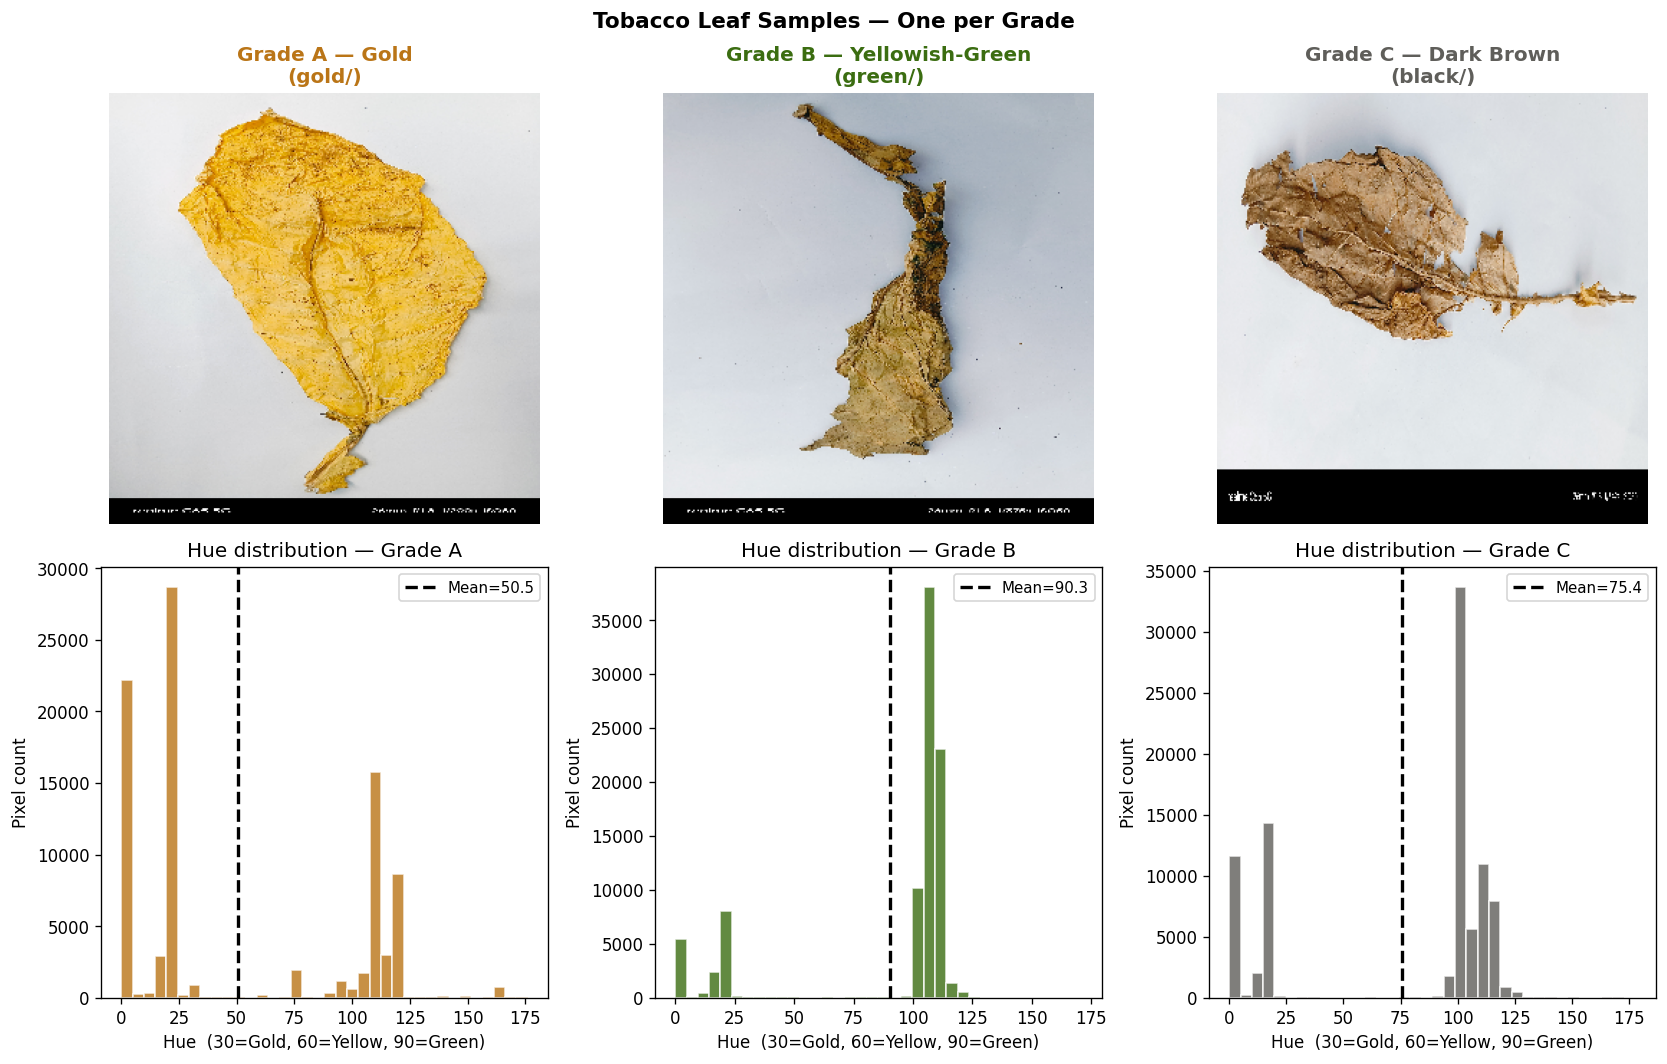

Saved: sample_visualization.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Tobacco Leaf Samples — One per Grade', fontsize=13, fontweight='bold')
colors = {'gold':'#BA7517','green':'#3B6D11','black':'#5F5E5A'}

for col, (folder, (label, grade, desc)) in enumerate(FOLDER_TO_GRADE.items()):
    imgs = glob.glob(os.path.join(DATASET_PATH, folder, '*.jpg'))[:1]
    if not imgs: continue
    img     = cv2.imread(imgs[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0,col].imshow(cv2.resize(img_rgb,(300,300)))
    axes[0,col].set_title(f'{grade} — {desc}\n({folder}/)',
                           color=colors[folder], fontweight='bold')
    axes[0,col].axis('off')

    hsv    = cv2.cvtColor(cv2.resize(img,(300,300)), cv2.COLOR_BGR2HSV)
    h_vals = hsv[:,:,0].flatten()
    axes[1,col].hist(h_vals, bins=36, color=colors[folder], alpha=0.8, edgecolor='white')
    axes[1,col].set_xlabel('Hue  (30=Gold, 60=Yellow, 90=Green)')
    axes[1,col].set_ylabel('Pixel count')
    axes[1,col].set_title(f'Hue distribution — {grade}')
    axes[1,col].axvline(np.mean(h_vals), color='black', lw=2, linestyle='--',
                         label=f'Mean={np.mean(h_vals):.1f}')
    axes[1,col].legend(fontsize=9)

plt.tight_layout()
plt.savefig('sample_visualization.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: sample_visualization.png')

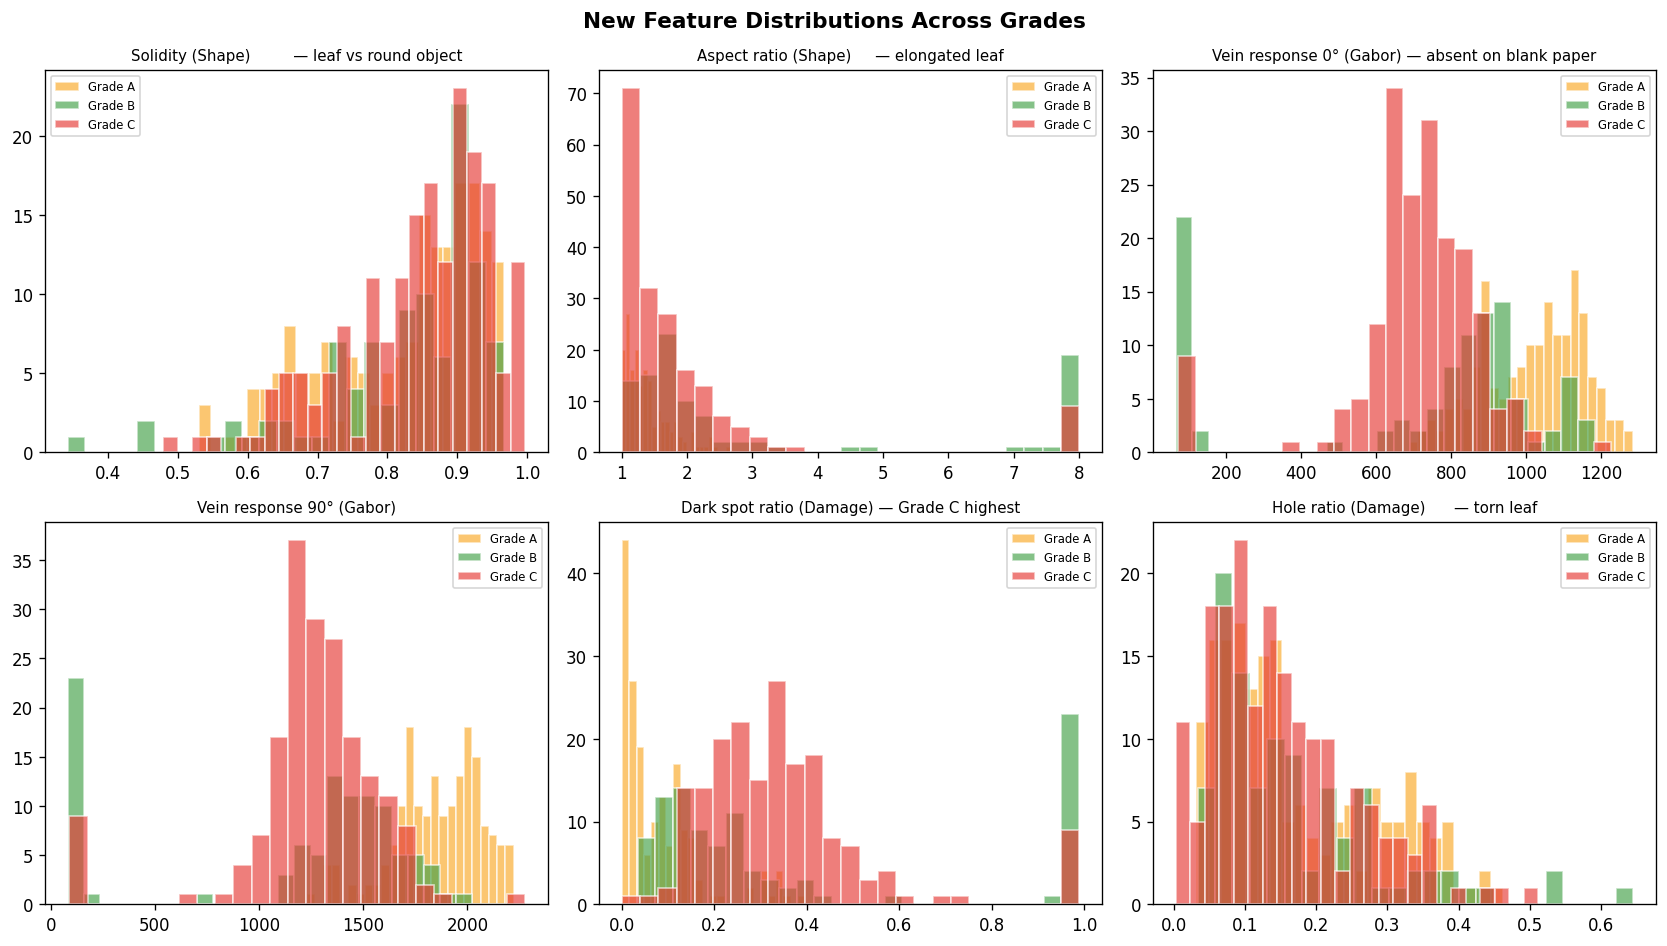

Saved: new_feature_distributions.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('New Feature Distributions Across Grades', fontsize=13, fontweight='bold')
gcolors = ['#f9a825','#43a047','#e53935']
gnames  = ['Grade A','Grade B','Grade C']

# Feature index map:
#  color=0:57, texture=57:127, shape=127:137, vein=137:153, damage=153:161, lbp=161:187
feat_info = [
    (127+2, 'Solidity (Shape)         — leaf vs round object'),
    (127+0, 'Aspect ratio (Shape)     — elongated leaf'),
    (137+0, 'Vein response 0° (Gabor) — absent on blank paper'),
    (137+4, 'Vein response 90° (Gabor)'),
    (153+0, 'Dark spot ratio (Damage) — Grade C highest'),
    (153+2, 'Hole ratio (Damage)      — torn leaf'),
]

for ax, (fi, fn) in zip(axes.flatten(), feat_info):
    for gi, (gc, gn) in enumerate(zip(gcolors, gnames)):
        vals = X[y==gi, fi]
        ax.hist(vals, bins=25, color=gc, alpha=0.65, label=gn, edgecolor='white')
    ax.set_title(fn, fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('new_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: new_feature_distributions.png')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train : {len(X_train)} images  (80%)')
print(f'Test  : {len(X_test)} images  (20%)')
print()
for folder, (idx, grade, desc) in FOLDER_TO_GRADE.items():
    print(f'  {grade}: train={np.sum(y_train==idx)}, test={np.sum(y_test==idx)}')

Train : 370 images  (80%)
Test  : 93 images  (20%)

  Grade A: train=142, test=36
  Grade B: train=80, test=20
  Grade C: train=148, test=37


In [9]:
pipelines = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            n_estimators=300, max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(
            kernel='rbf', C=10, gamma='scale',
            probability=True, class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1,
            max_depth=4, subsample=0.8,
            random_state=RANDOM_STATE
        ))
    ])
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

print('Cross-validating (5-fold)...\n')
for name, pipe in pipelines.items():
    t0     = time.time()
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    bar = '#' * int(scores.mean() * 40)
    print(f'  {name:<22}  {bar}')
    print(f'  {" "*22}  Acc: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%  ({time.time()-t0:.1f}s)\n')

BEST_NAME = max(results, key=lambda k: results[k].mean())
print(f'Best model: {BEST_NAME}  ({results[BEST_NAME].mean()*100:.2f}%)')

Cross-validating (5-fold)...

  Random Forest           #####################################
                          Acc: 93.24% +/- 1.71%  (13.4s)

  SVM (RBF)               #####################################
                          Acc: 94.05% +/- 1.83%  (6.7s)

  Gradient Boosting       #####################################
                          Acc: 94.59% +/- 1.21%  (30.5s)

Best model: Gradient Boosting  (94.59%)


In [10]:
print(f'Training {BEST_NAME} on full training set...')
best_pipeline = pipelines[BEST_NAME]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'\nTest accuracy: {acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=GRADE_LABELS))

Training Gradient Boosting on full training set...

Test accuracy: 93.55%

                 precision    recall  f1-score   support

 Grade A (Gold)       0.92      1.00      0.96        36
Grade B (Green)       0.85      0.85      0.85        20
Grade C (Black)       1.00      0.92      0.96        37

       accuracy                           0.94        93
      macro avg       0.92      0.92      0.92        93
   weighted avg       0.94      0.94      0.94        93



In [11]:
# ── Layer A: Rule-based checks ────────────────────────────────
def rule_based_check(img_bgr):
    """
    Fast checks before any ML model.
    Returns (is_valid: bool, reason: str)
    """
    img = cv2.resize(img_bgr, IMG_SIZE)
    _, mask = remove_background(img)
    fg_ratio = np.sum(mask > 0) / (IMG_SIZE[0] * IMG_SIZE[1])

    # Rule 1: Too little foreground -> blank or empty surface
    if fg_ratio < 0.08:
        return False, ('No leaf detected. '
                       'Please place a tobacco leaf on white paper and scan again.')

    # Rule 2: Foreground fills whole frame -> background not removed (not on white paper)
    if fg_ratio > 0.95:
        return False, ('The image looks like a blank surface or background. '
                       'Please scan the leaf on white paper only.')

    # Rule 3: Very low saturation -> white paper, grey surface
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    if np.mean(hsv[:,:,1]) < 18:
        return False, ('Image looks like a blank white or grey sheet, not a leaf.')

    # Rule 4: Vein check — leaf veins give strong Gabor response; paper does not
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    kernel = cv2.getGaborKernel((21,21), 4.0, 0, 10.0, 0.5, 0, cv2.CV_32F)
    resp   = cv2.filter2D(gray, cv2.CV_32F, kernel)
    vscore = float(np.mean(np.abs(resp[mask>0]))) if np.any(mask>0) else 0.0
    if vscore < 1.5:
        return False, ('No vein pattern detected. '
                       'This does not appear to be a leaf.')

    return True, 'ok'


# ── Layer B: One-Class SVM ────────────────────────────────────
# Trained ONLY on tobacco leaf features.
# Any image with a different feature profile gets rejected.
scaler_val   = StandardScaler()
X_val_scaled = scaler_val.fit_transform(X_train)

validator = OneClassSVM(
    kernel='rbf',
    nu=0.05,        # 5% of training images treated as outliers
    gamma='scale'
)
validator.fit(X_val_scaled)

# Self-test — how many of our own leaves does it accept?
accept_rate = np.mean(validator.predict(X_val_scaled) == 1) * 100
print(f'Validator accepts {accept_rate:.1f}% of tobacco training images.')
print('(Target: 90%+ means it correctly recognises real tobacco leaves.)')
print()
print('Validator and rule-checker both ready.')

Validator accepts 93.8% of tobacco training images.
(Target: 90%+ means it correctly recognises real tobacco leaves.)

Validator and rule-checker both ready.


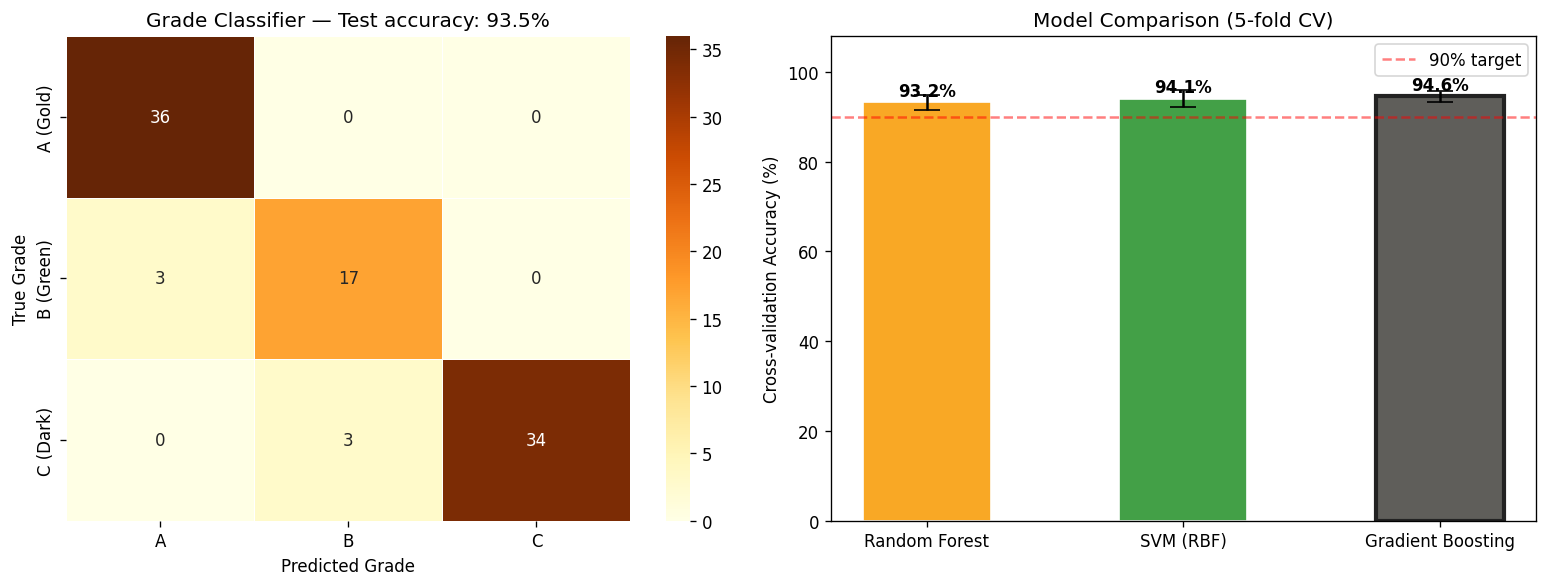

Saved: model_results.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['A','B','C'],
            yticklabels=['A (Gold)','B (Green)','C (Dark)'],
            linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_xlabel('Predicted Grade')
axes[0].set_ylabel('True Grade')
axes[0].set_title(f'Grade Classifier — Test accuracy: {acc*100:.1f}%')

# Model comparison
names  = list(results.keys())
means  = [results[n].mean()*100 for n in names]
stds   = [results[n].std()*100  for n in names]
bars   = axes[1].bar(names, means, yerr=stds, capsize=8, width=0.5,
                     color=['#f9a825','#43a047','#5F5E5A'], edgecolor='white')
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{m:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 108)
axes[1].set_ylabel('Cross-validation Accuracy (%)')
axes[1].set_title('Model Comparison (5-fold CV)')
axes[1].axhline(90, color='red', linestyle='--', alpha=0.5, label='90% target')
axes[1].legend()
bars[names.index(BEST_NAME)].set_edgecolor('#222')
bars[names.index(BEST_NAME)].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: model_results.png')

In [13]:
if BEST_NAME == 'Random Forest':
    clf  = best_pipeline.named_steps['clf']
    imps = clf.feature_importances_
    idx  = np.argsort(imps)[::-1][:25]

    def get_group(i):
        if   i < 57:  return 'Color',   '#f9a825'
        elif i < 127: return 'Texture',  '#43a047'
        elif i < 137: return 'Shape',    '#1565c0'
        elif i < 153: return 'Vein',     '#7b1fa2'
        elif i < 161: return 'Damage',   '#c62828'
        else:          return 'LBP',     '#37474f'

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(range(25), imps[idx], color=[get_group(i)[1] for i in idx], edgecolor='white')
    ax.set_xticks(range(25))
    ax.set_xticklabels([f'{get_group(i)[0]}\nF{i}' for i in idx], rotation=45, fontsize=8)
    ax.set_ylabel('Feature Importance')
    ax.set_title(f'Top 25 Feature Importances — {BEST_NAME}')
    legend_items = [
        mpatches.Patch(facecolor='#f9a825', label='Color'),
        mpatches.Patch(facecolor='#43a047', label='Texture'),
        mpatches.Patch(facecolor='#1565c0', label='Shape'),
        mpatches.Patch(facecolor='#7b1fa2', label='Vein'),
        mpatches.Patch(facecolor='#c62828', label='Damage'),
        mpatches.Patch(facecolor='#37474f', label='LBP'),
    ]
    ax.legend(handles=legend_items, loc='upper right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: feature_importance.png')
else:
    print(f'Feature importance chart requires Random Forest.')
    print(f'Best model is {BEST_NAME} — skipping this cell.')

Feature importance chart requires Random Forest.
Best model is Gradient Boosting — skipping this cell.


In [14]:
# ── Save grade classifier ─────────────────────────────────────
grader_bundle = {
    'model':        best_pipeline,
    'model_name':   BEST_NAME,
    'grade_labels': GRADE_LABELS,
    'short_labels': SHORT_LABELS,
    'img_size':     IMG_SIZE,
    'n_features':   X.shape[1],
    'test_acc':     acc,
    'folder_map':   FOLDER_TO_GRADE,
}
joblib.dump(grader_bundle, GRADER_FILE, compress=3)

# ── Save tobacco validator ────────────────────────────────────
validator_bundle = {
    'validator':  validator,
    'scaler':     scaler_val,
    'img_size':   IMG_SIZE,
    'n_features': X.shape[1],
}
joblib.dump(validator_bundle, VALIDATOR_FILE, compress=3)

print(f'Grade classifier  saved -> {GRADER_FILE}')
print(f'Tobacco validator saved -> {VALIDATOR_FILE}')
print()
print('Copy BOTH .pkl files to the same folder as streamlit_app.py')

Grade classifier  saved -> tobacco_grader.pkl
Tobacco validator saved -> tobacco_validator.pkl

Copy BOTH .pkl files to the same folder as streamlit_app.py


In [15]:
def predict_full_pipeline(img_bgr, grader_b, validator_b, verbose=True):
    """
    Complete two-stage prediction.

    Returns dict:
      is_tobacco : bool
      warning    : str or None
      grade      : 'A'/'B'/'C' or None
      grade_name : full label or None
      confidence : float or None
      proba      : list [pA, pB, pC] or None
    """
    # ── Stage 1a: Rule-based check ─────────────────────────────
    valid, reason = rule_based_check(img_bgr)
    if not valid:
        if verbose: print(f'  REJECTED (rule): {reason}')
        return {'is_tobacco':False,'warning':reason,
                'grade':None,'grade_name':None,'confidence':None,'proba':None}

    # ── Stage 1b: One-Class SVM ────────────────────────────────
    feats   = extract_features(img_bgr)
    val     = validator_b['validator']
    sc      = validator_b['scaler']
    fs      = sc.transform([feats])
    if val.predict(fs)[0] != 1:
        msg = ('This does not look like a tobacco leaf. '
               'Please scan a tobacco leaf only.')
        if verbose: print(f'  REJECTED (SVM): {msg}')
        return {'is_tobacco':False,'warning':msg,
                'grade':None,'grade_name':None,'confidence':None,'proba':None}

    # ── Stage 2: Grade prediction ──────────────────────────────
    model = grader_b['model']
    pred  = model.predict([feats])[0]
    proba = model.predict_proba([feats])[0]
    gl    = grader_b['grade_labels']
    sl    = grader_b['short_labels']
    conf  = proba[pred] * 100

    if verbose:
        print(f'  Tobacco leaf detected.')
        print(f'  Grade      : {sl[pred]}  —  {gl[pred]}')
        print(f'  Confidence : {conf:.1f}%')
        print(f'  All probs  : A={proba[0]*100:.1f}%  B={proba[1]*100:.1f}%  C={proba[2]*100:.1f}%')

    return {
        'is_tobacco': True,
        'warning':    None,
        'grade':      sl[pred],
        'grade_name': gl[pred],
        'confidence': round(conf, 1),
        'proba':      proba.tolist(),
    }


# ── Test on a real leaf ───────────────────────────────────────
gb = joblib.load(GRADER_FILE)
vb = joblib.load(VALIDATOR_FILE)

real_leaf = glob.glob(os.path.join(DATASET_PATH, 'gold', '*.jpg'))[0]
print('Test on a REAL tobacco leaf:')
result = predict_full_pipeline(cv2.imread(real_leaf), gb, vb)
print()
print('='*55)

Test on a REAL tobacco leaf:
  Tobacco leaf detected.
  Grade      : A  —  Grade A (Gold)
  Confidence : 100.0%
  All probs  : A=100.0%  B=0.0%  C=0.0%



In [16]:
# Synthetic test images — simulating what a vendor might accidentally scan
def make_test_img(kind):
    img = np.ones((400, 300, 3), dtype=np.uint8)
    if   kind == 'blank_paper':   img[:] = 240
    elif kind == 'dark_surface':  img[:] = 30
    elif kind == 'red_object':    img[:] = [0, 0, 200]
    elif kind == 'green_plastic': img[:] = [0, 160, 50]
    elif kind == 'hand':          img[:] = [120, 160, 200]
    return img

test_cases = [
    ('blank_paper',    'Blank white paper'),
    ('dark_surface',   'Dark table surface'),
    ('red_object',     'Red object'),
    ('green_plastic',  'Green plastic bag'),
    ('hand',           'Human hand / skin tone'),
]

print('Simulating non-tobacco inputs:\n')
print(f'  {"Input":<26}  Result')
print('  ' + '-'*50)

for kind, label in test_cases:
    img = make_test_img(kind)
    r   = predict_full_pipeline(img, gb, vb, verbose=False)
    if r['is_tobacco']:
        outcome = f'GRADE {r["grade"]} — {r["confidence"]}%  (should have been rejected)'
    else:
        outcome = f'REJECTED  "{r["warning"][:55]}..."'
    print(f'  {label:<26}  {outcome}')

Simulating non-tobacco inputs:

  Input                       Result
  --------------------------------------------------
  Blank white paper           REJECTED  "No leaf detected. Please place a tobacco leaf on white ..."
  Dark table surface          REJECTED  "The image looks like a blank surface or background. Ple..."
  Red object                  REJECTED  "The image looks like a blank surface or background. Ple..."
  Green plastic bag           REJECTED  "The image looks like a blank surface or background. Ple..."
  Human hand / skin tone      REJECTED  "The image looks like a blank surface or background. Ple..."


In [17]:
# Change this to any folder you want to classify
PREDICT_FOLDER = os.path.join(DATASET_PATH, 'gold')

images = (glob.glob(os.path.join(PREDICT_FOLDER,'*.jpg')) +
          glob.glob(os.path.join(PREDICT_FOLDER,'*.jpeg')) +
          glob.glob(os.path.join(PREDICT_FOLDER,'*.png')))

print(f'Found {len(images)} images in {PREDICT_FOLDER}\n')

rows = []
for p in tqdm(images[:50], ncols=60):
    try:
        img = cv2.imread(p)
        r   = predict_full_pipeline(img, gb, vb, verbose=False)
        rows.append({
            'File':       os.path.basename(p),
            'Is Tobacco': 'Yes' if r['is_tobacco'] else 'No',
            'Grade':      r['grade']      or 'N/A',
            'Grade Name': r.get('grade_name', 'N/A'),
            'Confidence': r['confidence'] or 'N/A',
            'Warning':    r['warning']    or '',
        })
    except Exception as e:
        pass

df = pd.DataFrame(rows)
print(f"\n  Accepted (tobacco)  : {len(df[df['Is Tobacco']=='Yes'])}")
print(f"  Rejected (non-tobacco): {len(df[df['Is Tobacco']=='No'])}")
print()
display(df.head(10))

df.to_csv('batch_predictions_v2.csv', index=False)
print('Saved: batch_predictions_v2.csv')

Found 178 images in C:\Users\BALU LOHITH REDDY\Downloads\tobacco leaves\gold



100%|███████████████████████| 50/50 [00:19<00:00,  2.59it/s]


  Accepted (tobacco)  : 49
  Rejected (non-tobacco): 1



,File,Is Tobacco,Grade,Grade Name,Confidence,Warning
0,IMG20250116132133.jpg,Yes,A,Grade A (Gold),100.0,
1,IMG20250116132425.jpg,Yes,A,Grade A (Gold),100.0,
2,IMG20250116132436.jpg,Yes,A,Grade A (Gold),100.0,
3,IMG20250116132450.jpg,Yes,A,Grade A (Gold),100.0,
4,IMG20250116132524.jpg,Yes,A,Grade A (Gold),100.0,
5,IMG20250116132540.jpg,Yes,A,Grade A (Gold),100.0,
6,IMG20250116132557.jpg,Yes,A,Grade A (Gold),100.0,
7,IMG20250116132622.jpg,Yes,A,Grade A (Gold),100.0,
8,IMG20250116132633.jpg,Yes,A,Grade A (Gold),100.0,
9,IMG20250116132648.jpg,Yes,A,Grade A (Gold),100.0,


Saved: batch_predictions_v2.csv


Testing on: feature_importance.png

  REJECTED (rule): No leaf detected. Please place a tobacco leaf on white paper and scan again.

Full Result Dictionary:
is_tobacco          : False
grade               : None
grade_name          : None
confidence          : None
proba               : None


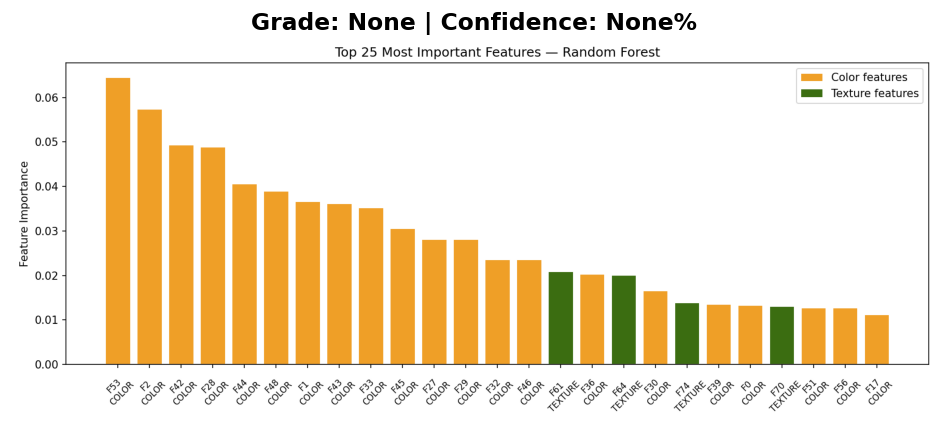

In [18]:
# Test the full pipeline on a single image
test_image_path = r'C:\Users\BALU LOHITH REDDY\Desktop\TBC\feature_importance.png'

# Read the image
test_img = cv2.imread(test_image_path)

if test_img is None:
    print(f"Error: Could not read image from {test_image_path}")
else:
    print(f"Testing on: {os.path.basename(test_image_path)}\n")
    
    # Run full pipeline
    result = predict_full_pipeline(test_img, gb, vb, verbose=True)
    
    print("\n" + "="*55)
    print("Full Result Dictionary:")
    print("="*55)
    for key, value in result.items():
        if key == 'proba' and value:
            print(f"{key:20}: A={value[0]*100:.2f}%  B={value[1]*100:.2f}%  C={value[2]*100:.2f}%")
        else:
            print(f"{key:20}: {value}")
    
    # Display the image
    img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Grade: {result['grade']} | Confidence: {result['confidence']}%", 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Testing on: WIN_20260604_18_05_32_Pro.jpg

  REJECTED (SVM): This does not look like a tobacco leaf. Please scan a tobacco leaf only.

Full Result Dictionary:
is_tobacco          : False
grade               : None
grade_name          : None
confidence          : None
proba               : None


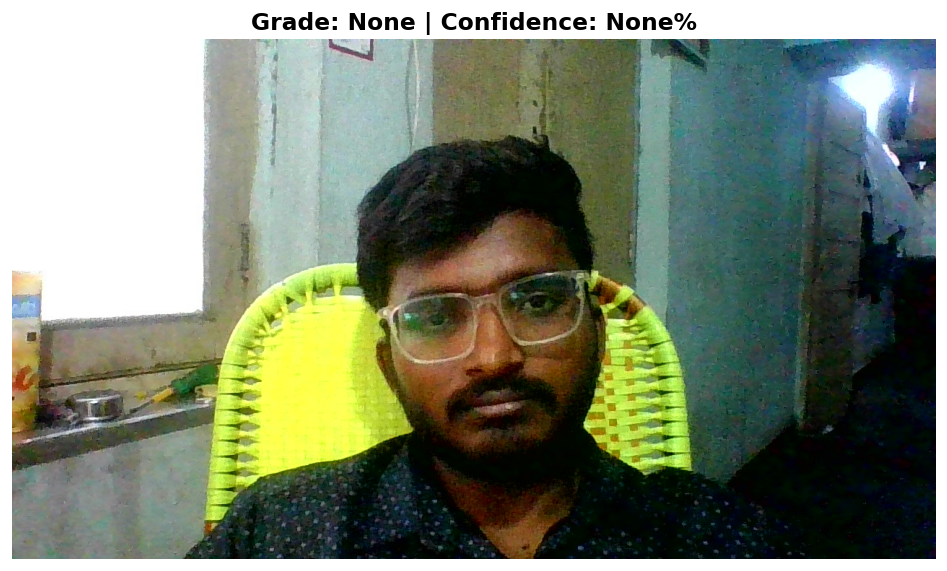

In [19]:
# Test the full pipeline on a single image from a file path
test_image_path = r'C:\Users\BALU LOHITH REDDY\Pictures\Camera Roll\WIN_20260604_18_05_32_Pro.jpg'

# Read the image
test_img = cv2.imread(test_image_path)

if test_img is None:
    print(f"Error: Could not read image from {test_image_path}")
else:
    print(f"Testing on: {os.path.basename(test_image_path)}\n")
    
    # Run full pipeline
    result = predict_full_pipeline(test_img, gb, vb, verbose=True)
    
    print("\n" + "="*55)
    print("Full Result Dictionary:")
    print("="*55)
    for key, value in result.items():
        if key == 'proba' and value:
            print(f"{key:20}: A={value[0]*100:.2f}%  B={value[1]*100:.2f}%  C={value[2]*100:.2f}%")
        else:
            print(f"{key:20}: {value}")
    
    # Display the image
    img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Grade: {result['grade']} | Confidence: {result['confidence']}%", 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()